# LQG-регулятор активной подвески автомобиля

Пример из MATLAB-версии курса (`19_auto1.m`, презентация `18_Lesson8_2dof15.ppt`) к разделу «Синтез управления» главы 6.

**Замечание к MATLAB-программе.** В ней фильтр Калмана вызывается как `kalman(sys3, 1, 0.01, 0, controls, feedout)`: номера каналов стоят в позициях «измеряемые выходы, известные входы». При этом измеряемым оказывается выход 1, а известным — вход 2 (дорога). Замыкание же выполнено по выходу 2 и входу 1: `feedback(sys3, sysreg, controls, feedout)`. Здесь использован согласованный вариант: **управляется вход 1 (привод), измеряется выход 2**, шум процесса — профиль дороги.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

np.set_printoptions(precision=4, suppress=True)

## Постановка задачи

*По материалам занятия 8 MATLAB-версии курса (`18_Lesson8_2dof15.ppt`).*

### Двухмассовая модель подвески

![Двухмассовая модель подвески](img/suspension_scheme.png)

Кузов массы $M$ опирается на колесо массы $m$ (неподрессоренная масса) через пружину жёсткости $c_p$ и демпфер $k_a$. Параллельно им установлен привод $A$, развивающий управляющую силу $Mu$ по команде бортового вычислителя (БЦВМ). Колесо опирается на дорогу через шину жёсткости $c_s$ (её демпфированием $k_s$ пренебрегаем). Координаты $x_1$ (кузов) и $x_2$ (колесо) отсчитываются от положения равновесия, $q$ — высота профиля дороги.

Уравнения движения:
$$
\begin{aligned}
M\ddot x_1 &= -c_p(x_1 - x_2) - k_a(\dot x_1 - \dot x_2) + Mu,\\
m\ddot x_2 &= c_p(x_1 - x_2) + k_a(\dot x_1 - \dot x_2) - c_s(x_2 - q) - Mu.
\end{aligned}
$$

Выходы системы:
- ход подвески (рессоры) $x_1 - x_2$;
- деформация шины $x_2 - q$;
- ускорение кузова $\ddot x_1$.

Вектор состояния $x = (x_1, \dot x_1, x_2, \dot x_2)^T$, входы — управление $u$ и профиль дороги $q$: $\dot x = Ax + B\,(u, q)^T$, $y = Cx + D\,(u, q)^T$.

### Матрицы системы

Введём обозначения
$$
\frac{c_p}{M} = \omega_1^2, \qquad \frac{k_a}{M} = 2\xi_1\omega_1, \qquad \frac{c_s}{m} = \omega_2^2, \qquad \frac{m}{M} = \mu .
$$
Тогда
$$
A = \begin{pmatrix}
0 & 1 & 0 & 0\\
-\omega_1^2 & -2\xi_1\omega_1 & \omega_1^2 & 2\xi_1\omega_1\\
0 & 0 & 0 & 1\\
\dfrac{\omega_1^2}{\mu} & \dfrac{2\xi_1\omega_1}{\mu} & -\dfrac{\omega_1^2}{\mu} - \omega_2^2 & -\dfrac{2\xi_1\omega_1}{\mu}
\end{pmatrix},
\qquad
B = \begin{pmatrix} 0 & 0\\ 1 & 0\\ 0 & 0\\ -\dfrac{1}{\mu} & \omega_2^2 \end{pmatrix},
$$
$$
C = \begin{pmatrix}
1 & 0 & -1 & 0\\
0 & 0 & 1 & 0\\
-\omega_1^2 & -2\xi_1\omega_1 & \omega_1^2 & 2\xi_1\omega_1
\end{pmatrix},
\qquad
D = \begin{pmatrix} 0 & 0\\ 0 & -1\\ 1 & 0 \end{pmatrix}.
$$
Строки $C$ и $D$ соответствуют выходам в порядке: ход подвески, деформация шины, ускорение кузова.

### Модель дороги $R(s)$

Профиль дороги при движении со скоростью $V$ описывается случайным процессом со спектральной плотностью
$$
\Phi_q(\omega) = a\,\frac{\sigma^2}{\pi}\,\frac{1}{\lambda^2 + a^2}.
$$
Такой процесс получается на выходе формирующего фильтра
$$
\dot q + aVq = w, \qquad M\bigl[w(t)\,w(t+\tau)\bigr] = 2\sigma^2 aV\,\delta(\tau),
\qquad R(s) = \frac{1}{s + aV},
$$
на вход которого подаётся белый шум $w$ (обозначение $\lambda$ в формуле спектральной плотности — как на слайде занятия, где оно не расшифровано). Параметры для типичных покрытий:

| Покрытие | $a$, 1/м | $\sigma$, м |
|---|---|---|
| асфальт | 0.15 | 0.0033 |
| бетон | 0.20 | 0.0056 |
| гравий | 0.40 | 0.0120 |

### Модель привода $Q(s)$

Привод отрабатывает команду $\hat u$ с запаздыванием и описывается апериодическим звеном
$$
Q(s) = \frac{1}{\tau_a s + 1}, \qquad \tau_a = 1/60 \text{ с}.
$$

### Модель водителя $P(s)$

Восприятие вертикальных колебаний человеком зависит от частоты: наиболее чувствительна полоса 4–8 Гц (резонансы внутренних органов). Её описывает формирующий фильтр, аппроксимирующий частотную характеристику стандарта ISO 2631. Выход фильтра, на вход которого подаётся ускорение кузова, — **показатель плавности хода**:
$$
P(s) = \frac{b_1 s + b_0}{s^2 + a_1 s + a_0} = \frac{50s + 500}{s^2 + 50s + 1200}.
$$

### Структурная схема

![Структурная схема системы с регулятором](img/suspension_blocks.png)

Обобщённый объект $G(s)$ объединяет модель дороги, двухмассовую модель, привод и фильтр водителя. Его входы — шум $w$, формирующий профиль дороги, и управление $u$. Выходы — регулируемые величины $z$ (ход подвески, деформация шины, показатель плавности хода) и измерение $y$, содержащее погрешность $v$.

**Задача:** построить регулятор $K(s)$ по измерению $y$, уменьшающий показатель плавности хода и не допускающий чрезмерного хода подвески и деформации шины. Ниже регулятор строится как линейно-квадратично-гауссовский (LQG).

**Замечания к MATLAB-программе.**
- Коэффициент формирующего фильтра дороги задан в программе как `sig*2*a*V`, то есть $2\sigma aV$. По приведённой выше формуле интенсивность шума $w$ равна $2\sigma^2 aV$, поэтому при единичном белом шуме коэффициент должен быть $\sigma\sqrt{2aV}$. При принятых значениях это 0.025, а не 0.112.
- В программе взяты $\sigma = 0.0056$ (бетон), но $a = 1$ вместо 0.20 из таблицы.

Ниже, чтобы результаты совпадали с MATLAB-версией, сохранены значения программы; попробуйте заменить их значениями из таблицы.

## Модель

Все блоки задаются в пространстве состояний. Скалярные передаточные функции переводятся в пространство состояний по отдельности (`ct.ss(ct.tf(...))`), поэтому пакет `slycot` не нужен.

In [2]:
w1, w2 = 2 * np.pi, 23 * np.pi    # парциальные частоты кузова и колеса, рад/с
XS = 0.025                        # относительное демпфирование подвески
mu = 0.1                          # отношение масс колеса и кузова
tau = 1 / 60                      # постоянная времени привода, с
a, sig, V = 1, 0.0056, 10         # параметры профиля дороги и скорость, м/с

A = np.array([[0, 1, 0, 0],
              [-w1**2, -2*XS*w1, w1**2, 2*XS*w1],
              [0, 0, 0, 1],
              [w1**2/mu, 2*XS*w1/mu, -w1**2/mu - w2**2, -2*XS*w1/mu]])
B = np.array([[0, 0], [1, 0], [0, 0], [-1/mu, w2**2]])     # входы: привод, дорога
C = np.array([[1, 0, -1, 0],                                 # ход подвески
              [0, 0, 1, 0],                                  # перемещение колеса (с D: деформация шины)
              [-w1**2, -2*XS*w1, w1**2, 2*XS*w1]])           # ускорение кузова
D = np.array([[0, 0], [0, -1], [1, 0]])
car = ct.ss(A, B, C, D)

drive = ct.ss(ct.tf(1, [tau, 1]))                 # привод
road = ct.ss(ct.tf(sig * 2 * a * V, [1, a * V]))  # формирующий фильтр профиля дороги
driver = ct.ss(ct.tf([50, 500], [1, 50, 1200]))   # восприятие ускорения водителем
one = ct.ss([], [], [], [[1.0]])                  # безынерционное звено

# append -- блочно-диагональное объединение; series -- последовательное соединение
sys2 = ct.series(ct.append(drive, road), car)
sys3 = ct.series(sys2, ct.append(one, one, driver))
print('состояний:', sys3.nstates, ' входов:', sys3.ninputs, ' выходов:', sys3.noutputs)

# порядок состояний в series: сначала первая система (привод, дорога), затем кузов/колесо
i_car = drive.nstates + road.nstates
print('индекс первой переменной кузова:', i_car)

состояний: 8  входов: 2  выходов: 3
индекс первой переменной кузова: 2


In [3]:
A3, B3, C3, D3 = sys3.A, sys3.B, sys3.C, sys3.D
Bu, Bw = B3[:, [0]], B3[:, [1]]          # управление (привод) и шум (дорога)
Du = D3[:, [0]]
y_idx = 1                                 # измеряемый выход (в MATLAB -- номер 2)
Cy, Dyu = C3[[y_idx]], D3[[y_idx]][:, [0]]

print('ранг матрицы управляемости:', np.linalg.matrix_rank(ct.ctrb(A3, Bu)), 'из', sys3.nstates)
print('ранг матрицы наблюдаемости:', np.linalg.matrix_rank(ct.obsv(A3, Cy)), 'из', sys3.nstates)
print('полюсы объекта:', np.sort_complex(np.linalg.eigvals(A3)))

ранг матрицы управляемости: 7 из 8
ранг матрицы наблюдаемости: 6 из 8
полюсы объекта: [-60.     +0.j     -25.    -23.9792j -25.    +23.9792j -10.     +0.j
  -1.5923-74.9346j  -1.5923+74.9346j  -0.1356 -6.0558j  -0.1356 +6.0558j]


Система управляема и наблюдаема не полностью: движение фильтра профиля дороги не зависит от управления, а часть переменных не проявляется в измеряемом выходе. Но все неуправляемые и ненаблюдаемые движения устойчивы, поэтому регулятор и фильтр Калмана построить можно.

## Линейно-квадратичный регулятор по выходам

В MATLAB использовалась функция `lqry`: веса заданы для выходов $z$. В `control` такой функции нет. Веса пересчитываются к весам для состояний, $Q = C^TQ_zC$, $N = C^TQ_zD$, $R = R_u + D^TQ_zD$, и вызывается `ct.lqr`.

In [4]:
Qz = np.eye(3)
Ru = np.array([[1.0]])
Q = C3.T @ Qz @ C3
N = C3.T @ Qz @ Du
R = Ru + Du.T @ Qz @ Du
K, S, E = ct.lqr(A3, Bu, Q, R, N)
print('полюсы A - B K:', np.sort_complex(E))

полюсы A - B K: [-44.9624-26.1024j -44.9624+26.1024j -29.9031 +0.j     -10.     +0.j
  -1.7704-74.5624j  -1.7704+74.5624j  -1.1692 -5.6259j  -1.1692 +5.6259j]


## Фильтр Калмана

Шум процесса — вход дороги с единичной интенсивностью, шум измерения — с интенсивностью 0.01.

In [5]:
L, P, E_kf = ct.lqe(A3, Bw, Cy, np.array([[1.0]]), np.array([[0.01]]))
print('полюсы фильтра:', np.sort_complex(E_kf))

полюсы фильтра: [-60.     +0.j     -25.    -23.9792j -25.    +23.9792j -10.0003 +0.j
  -1.6739-74.9322j  -1.6739+74.9322j  -0.1372 -6.0557j  -0.1372 +6.0557j]


## LQG-регулятор и замкнутая система

Регулятор получает измеряемый выход и выдаёт управление $u = -K\tilde x$. Замыкание по выбранным каналам выполняется функцией `ct.interconnect`: сигналы соединяются по именам. Внешним входом замкнутой системы остаётся профиль дороги.

In [6]:
Ac = A3 - L @ Cy - (Bu - L @ Dyu) @ K
reg = ct.ss(Ac, L, -K, 0, inputs='y', outputs='u', name='reg')
plant = ct.ss(A3, B3, C3, D3, inputs=['u', 'w'], outputs=['z1', 'y', 'z3'], name='plant')
cl = ct.interconnect([plant, reg], inplist=['w'], outlist=['z1', 'y', 'z3'])

print('состояний замкнутой системы:', cl.nstates)
print('max Re(полюсы) =', cl.poles().real.max())

состояний замкнутой системы: 16
max Re(полюсы) = -0.1371572100834002


## Свободные колебания: разомкнутая и замкнутая системы

Начальное отклонение кузова $x_1 = 1$. Как и в MATLAB-программе, начальная оценка регулятора совпадает с истинным состоянием объекта. В `interconnect` состояния идут в порядке перечисления систем: сначала объект, затем регулятор.

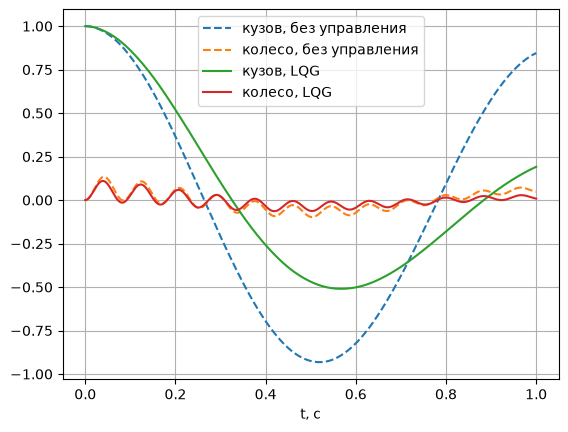

In [7]:
T = np.linspace(0, 1, 1001)
x0_plant = np.zeros(sys3.nstates)
x0_plant[i_car] = 1.0
r_open = ct.initial_response(sys3, T, X0=x0_plant)
r_cl = ct.initial_response(cl, T, X0=np.r_[x0_plant, x0_plant])

plt.plot(T, r_open.states[i_car], '--', label='кузов, без управления')
plt.plot(T, r_open.states[i_car + 2], '--', label='колесо, без управления')
plt.plot(T, r_cl.states[i_car], label='кузов, LQG')
plt.plot(T, r_cl.states[i_car + 2], label='колесо, LQG')
plt.xlabel('t, с')
plt.legend()
plt.grid(True)
plt.show()

## Частотные характеристики

Сравним сингулярные числа частотных матриц разомкнутой (от входа дороги) и замкнутой систем. В MATLAB для этого использовалась функция `sigma`.

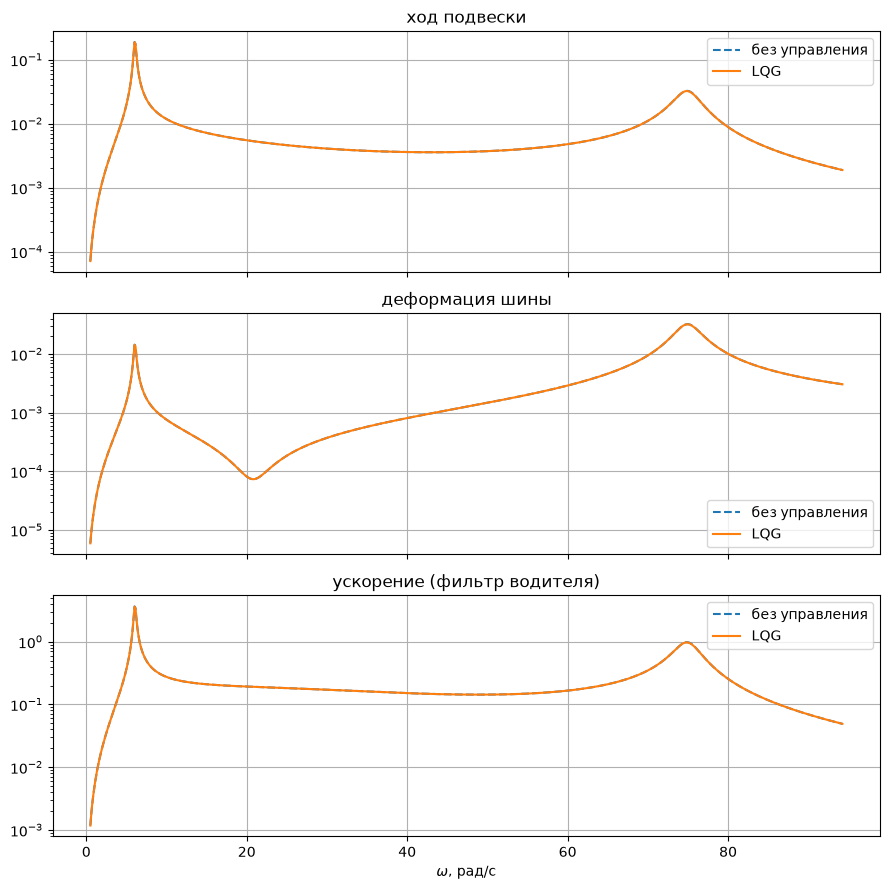

In [8]:
w = np.linspace(0.5, 30 * np.pi, 800)
fr_open = ct.frequency_response(sys3[:, 1], w)    # все выходы, вход «дорога»
fr_cl = ct.frequency_response(cl, w)

names = ['ход подвески', 'деформация шины', 'ускорение (фильтр водителя)']
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
for i, ax in enumerate(axes):
    ax.semilogy(w, fr_open.magnitude[i, 0], '--', label='без управления')
    ax.semilogy(w, fr_cl.magnitude[i, 0], label='LQG')
    ax.set_title(names[i])
    ax.grid(True)
    ax.legend()
axes[-1].set_xlabel(r'$\omega$, рад/с')
plt.tight_layout()
plt.show()

С весами из MATLAB-программы регулятор почти не меняет частотные характеристики: пики снижаются лишь на несколько процентов. Причина — в интенсивностях шумов. Профиль дороги проходит через фильтр с малым коэффициентом, а шум измерений задан сравнительно большим, поэтому фильтр Калмана почти не доверяет измерениям. Его полюсы ($-0.137 \pm 6.06i$) практически совпадают с полюсами кузова, и оценка колебаний кузова запаздывает. Свободные колебания выше гасятся только потому, что начальная оценка совпадала с истинным состоянием.

## Влияние интенсивности шума измерений

Повторим синтез фильтра Калмана при меньшей интенсивности шума измерений и сравним результаты.

RN = 0.01: max Re(полюсы) = -0.137
RN = 1e-06: max Re(полюсы) = -1.169


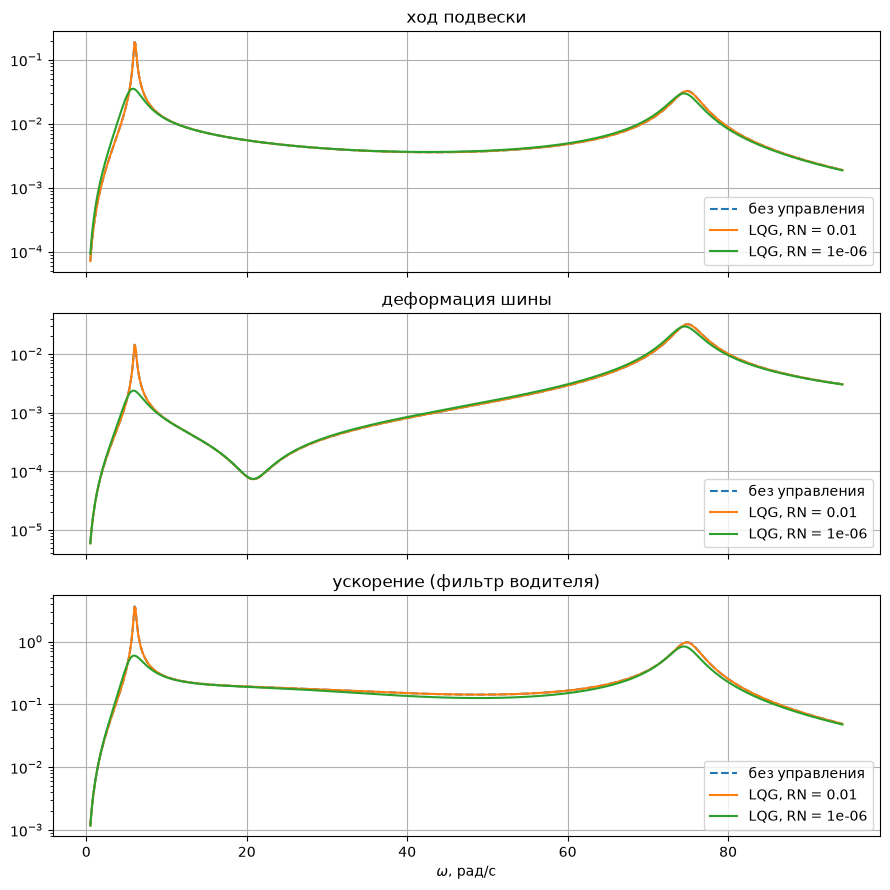

In [9]:
def lqg_closed_loop(RN):
    """Замкнутая система с LQG-регулятором при интенсивности шума измерений RN."""
    L, _, _ = ct.lqe(A3, Bw, Cy, np.array([[1.0]]), np.array([[RN]]))
    Ac = A3 - L @ Cy - (Bu - L @ Dyu) @ K
    reg = ct.ss(Ac, L, -K, 0, inputs='y', outputs='u', name='reg')
    return ct.interconnect([plant, reg], inplist=['w'], outlist=['z1', 'y', 'z3'])


fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
for i, ax in enumerate(axes):
    ax.semilogy(w, fr_open.magnitude[i, 0], '--', label='без управления')
for RN in (0.01, 1e-6):
    cl_RN = lqg_closed_loop(RN)
    fr = ct.frequency_response(cl_RN, w)
    print(f'RN = {RN:g}: max Re(полюсы) = {cl_RN.poles().real.max():.3f}')
    for i, ax in enumerate(axes):
        ax.semilogy(w, fr.magnitude[i, 0], label=f'LQG, RN = {RN:g}')
for i, ax in enumerate(axes):
    ax.set_title(names[i])
    ax.grid(True)
    ax.legend()
axes[-1].set_xlabel(r'$\omega$, рад/с')
plt.tight_layout()
plt.show()

При $R_N = 10^{-6}$ фильтр быстрее отслеживает колебания кузова, резонансные пики хода подвески и ускорения снижаются в 4–5 раз, а запас устойчивости растёт. Цена — бо́льшая чувствительность к реальному шуму датчика: выбор интенсивностей шумов — такая же часть синтеза, как выбор весов функционала.

**Что попробовать:**
- увеличьте вес ускорения в $Q_z" и сравните АЧХ по ускорению и ходу подвески;
- измеряйте вместо деформации шины ход подвески (`y_idx = 0`);
- постройте импульсные реакции (`ct.impulse_response`) разомкнутой и замкнутой систем.

## Дополнения из `19_auto1.m`

Сингулярные числа частотных матриц от входа дороги (аналог `sigma(sys3, syscl, w)`) и импульсные реакции разомкнутой и замкнутой систем (аналог `impulse`).

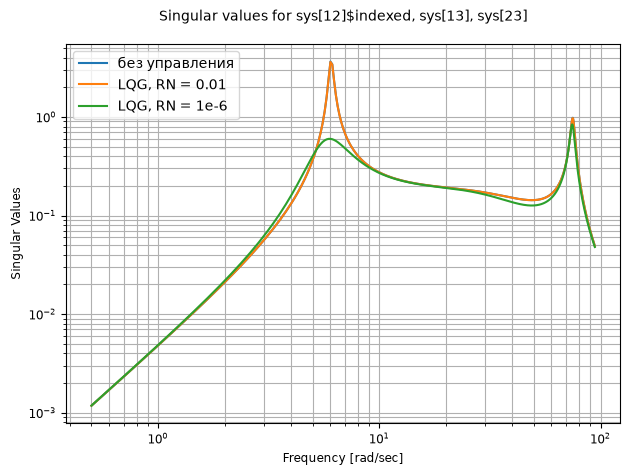

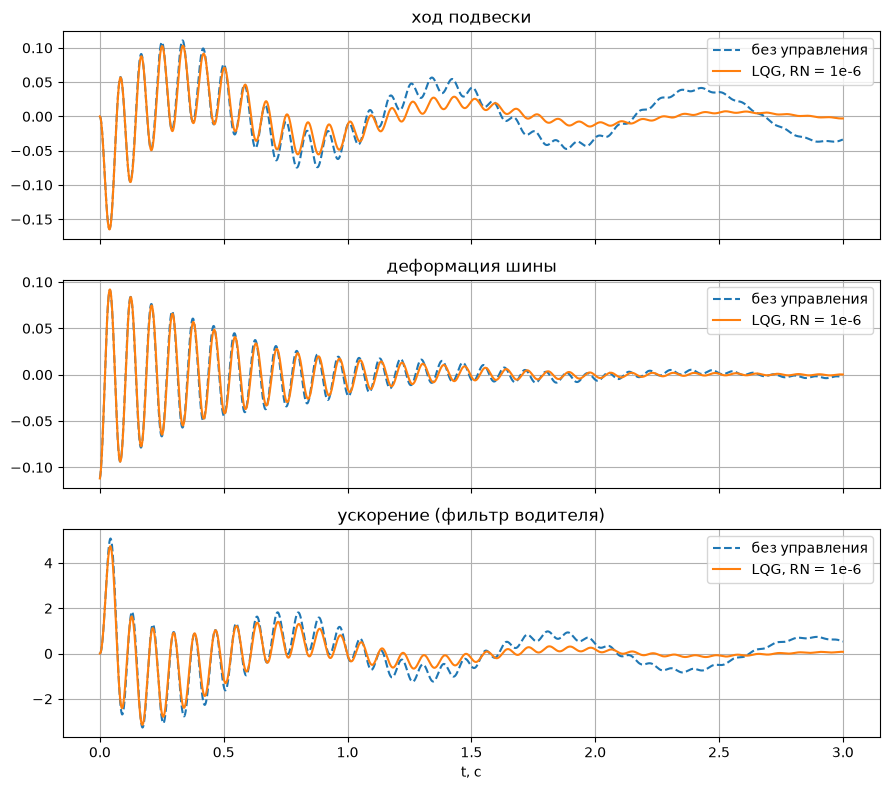

In [10]:
cl_best = lqg_closed_loop(1e-6)          # регулятор с малым шумом измерений
ct.singular_values_plot([sys3[:, 1], cl, cl_best], w)
plt.legend(['без управления', 'LQG, RN = 0.01', 'LQG, RN = 1e-6'])
plt.show()

T = np.linspace(0, 3, 3001)
r_open = ct.impulse_response(sys3[:, 1], T)
r_cl = ct.impulse_response(cl_best, T)
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(T, r_open.outputs[i, 0], '--', label='без управления')
    ax.plot(T, r_cl.outputs[i, 0], label='LQG, RN = 1e-6')
    ax.set_title(names[i])
    ax.grid(True)
    ax.legend()
axes[-1].set_xlabel('t, с')
plt.tight_layout()
plt.show()